In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  

In [2]:
"""加载数据集，划分训练集和测试集，标准化数据"""
data = datasets.load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22) # 划分训练集和测试集
ss = StandardScaler() # 标准化
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [3]:
"""训练模型，评估模型"""
lr = LogisticRegression() # 训练模型
lr.fit(X_train, y_train)
print("训练集上准确率：", lr.score(X_train, y_train)) # 评估模型
print("测试集上准确率：", lr.score(X_test, y_test)) # 评估模型

训练集上准确率： 0.95
测试集上准确率： 0.9666666666666667


In [4]:
"""验证集调参"""
from sklearn.model_selection import GridSearchCV
param_dict = {"C": [0.1, 1, 10, 100]}
grid = GridSearchCV(lr, param_grid=param_dict, cv=3) # 交叉验证
grid.fit(X_train, y_train)
print("验证集上最佳参数：", grid.best_params_)
print("验证集上最佳结果：", grid.best_score_)
print("测试集上准确率：", grid.score(X_test, y_test)) # 评估模型

验证集上最佳参数： {'C': 10}
验证集上最佳结果： 0.975
测试集上准确率： 1.0


In [5]:
"""测试集报告模型性能"""
from sklearn.metrics import classification_report
y_predict = grid.predict(X_test)
print("测试集上分类报告：\n", classification_report(y_test, y_predict, target_names=data.target_names))

测试集上分类报告：
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         6
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



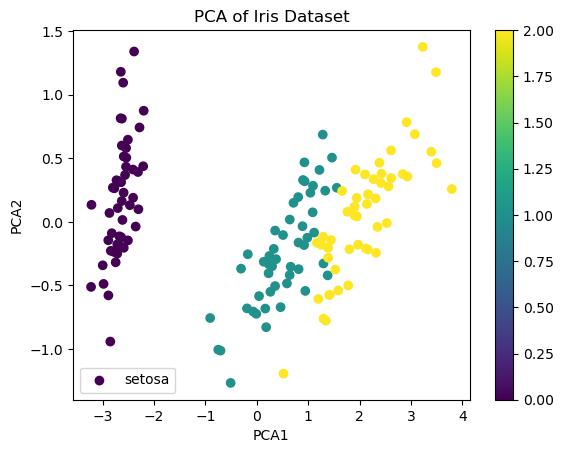

In [9]:
"""模型可视化"""
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Iris Dataset")
plt.colorbar() # 显示颜色条
plt.legend(data.target_names) # 显示图例
plt.show()

In [10]:
"""扩大数据集，构建或获取更大数据集，提升模型泛化能力"""
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=22) # 随机森林
rf.fit(X_train, y_train)
print("训练集上准确率：", rf.score(X_train, y_train)) # 评估模型
print("测试集上准确率：", rf.score(X_test, y_test)) # 评估模型

训练集上准确率： 0.9916666666666667
测试集上准确率： 0.9333333333333333


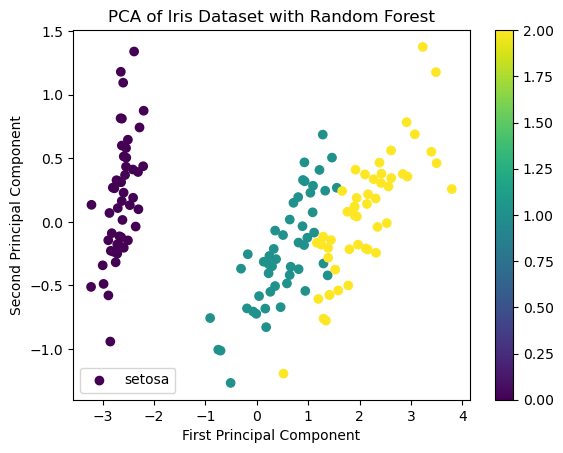

In [11]:
"""可视化泛化后的模型"""
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Iris Dataset with Random Forest")
plt.colorbar() # 显示颜色条
plt.legend(data.target_names) # 显示图例
plt.show()